Workflow:

VCF file -- PLINK convert -- LD Pruning -- PCA analysis -- ADMIXTURE Analysis


Using Chr1 took way too long (>1h) so Chr7 was used

I also filtered the amount of variants down to 10000, though i did the PCA with the full set

In [6]:
!pwd

/Users/amira/Desktop/BIO392/exercises/day10/chr7


In [7]:
!bcftools view -h /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
!bcftools view -H /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz | head

##fileformat=VCFv4.3
##FILTER=<ID=PASS,Description="All filters passed">
##fileDate=31052018_15h52m43s
##source=IGSRpipeline
##reference=ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
##FORMAT=<ID=GT,Number=1,Type=String,Description="Phased Genotype">
##contig=<ID=chr7>
##INFO=<ID=AF,Number=A,Type=Float,Description="Estimated allele frequency in the range (0,1)">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Total number of alternate alleles in called genotypes">
##INFO=<ID=NS,Number=1,Type=Integer,Description="Number of samples with data">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=EAS_AF,Number=A,Type=Float,Description="Allele frequency in the EAS populations calculated from AC and AN, in the range (0,1)">
##INFO=<ID=EUR_AF,Number=A,Type=Float,Description="Allele frequency in the EUR populations calculated from AC and AN, in the range (0,1

In [8]:
%%bash
bcftools view \
  --threads 4 \
  -m2 -M2 \
  -v snps \
  -i 'MAF>0.01' \
  -Oz \
  -o chr7_filtered.vcf.gz \
    /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

Convert VCF → PLINK format

In [9]:
%%bash
plink \
  --vcf /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz \
  --make-bed \
  --out chr7_raw \
  --double-id \
  --vcf-half-call missing \
  --biallelic-only strict

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_raw.log.
Options in effect:
  --biallelic-only strict
  --double-id
  --make-bed
  --out chr7_raw
  --vcf /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz
  --vcf-half-call missing

8192 MB RAM detected; reserving 4096 MB for main workspace.
--vcf: chr7_raw-temporary.bed + chr7_raw-temporary.bim + chr7_raw-temporary.fam
written.
708669 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_raw.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990

In [10]:
!ls -lh /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz

-rw-r--r--@ 1 amira  staff   402M May  4 14:00 /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz


Basic QC (missingness + MAF):

Removes:
* bad SNPs
* bad individuals
* rare variants

In [11]:
%%bash
plink \
  --bfile chr7_raw \
  --geno 0.05 \
  --mind 0.05 \
  --maf 0.05 \
  --make-bed \
  --out chr7_qc

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_qc.log.
Options in effect:
  --bfile chr7_raw
  --geno 0.05
  --maf 0.05
  --make-bed
  --mind 0.05
  --out chr7_qc

8192 MB RAM detected; reserving 4096 MB for main workspace.
708669 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_qc.nosex .
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
0 variants removed due to missing genotype data (--geno).
30

In [12]:
%%bash
plink \
  --bfile chr7_qc \
  --indep-pairwise 100 5 0.1 \
  --out chr7_prune

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_prune.log.
Options in effect:
  --bfile chr7_qc
  --indep-pairwise 100 5 0.1
  --out chr7_prune

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_prune.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
401332 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 391305 variants from chromosome 7, leaving 1

In [14]:
%%bash
plink \
  --bfile chr7_qc \
  --extract chr7_prune.prune.in \
  --make-bed \
  --out chr7_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pruned.log.
Options in effect:
  --bfile chr7_qc
  --extract chr7_prune.prune.in
  --make-bed
  --out chr7_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_pruned.nosex .
--extract: 401332 variants remaining.


Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
401332 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr7_pruned.bed + chr7_pruned.bim + chr7_pruned.fam ... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949596979899done.


In [27]:
%%bash
# Randomly subsample to 10,000 SNPs
plink \
  --bfile chr7_pruned \
  --thin-count 10000 \
  --make-bed \
  --out chr7_pruned_10k

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pruned_10k.log.
Options in effect:
  --bfile chr7_pruned
  --make-bed
  --out chr7_pruned_10k
  --thin-count 10000

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_pruned_10k.nosex .
--thin-count: 391332 variants removed (10000 remaining).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
10000 variants and 2548 people pass filters and QC.


PCA    

In [31]:
%%bash
plink \
  --bfile chr7_pruned \
  --pca 20 \
  --out chr7_pca

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pca.log.
Options in effect:
  --bfile chr7_pruned
  --out chr7_pca
  --pca 20

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_pca.nosex .
Using up to 4 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
401332 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to chr7_pca.

PCA Plot

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



pca = pd.read_table("/Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_pca.eigenvec", header=None, delim_whitespace=True)
pca.head()

/var/folders/7_/v_n1yvl962q_bs_bb3jphtzr0000gn/T/ipykernel_73701/2144239407.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca = pd.read_table("/Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_pca.eigenvec", header=None, delim_whitespace=True)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,HG00096,HG00096,-0.011514,-0.025321,-0.011876,-0.017544,0.005835,-0.017336,-0.020886,-0.009711,...,-0.014100,-0.009080,0.014067,-0.013829,-0.030849,-0.008826,-0.011704,0.000771,-0.020063,-0.037196
1,HG00097,HG00097,-0.011161,-0.026350,-0.005615,-0.014179,-0.016896,0.031228,0.017682,0.013234,...,0.018145,-0.000873,-0.008026,-0.001430,-0.031546,-0.016507,-0.005728,-0.013406,0.014598,0.004962
2,HG00099,HG00099,-0.011585,-0.028989,-0.005389,-0.023955,-0.009148,-0.049204,0.024590,0.012206,...,-0.016347,0.002707,-0.011033,0.014186,-0.015358,0.002502,0.035719,0.016003,0.018775,-0.019414
3,HG00100,HG00100,-0.010871,-0.030574,-0.008798,-0.015387,0.002149,0.020226,-0.017654,0.001701,...,0.011596,0.005125,0.010247,0.010216,-0.013292,-0.000932,-0.019070,-0.002398,0.011228,0.012959
4,HG00101,HG00101,-0.011255,-0.027605,-0.014285,-0.010259,-0.014271,0.019914,-0.015478,0.006294,...,-0.001254,0.002452,-0.006004,0.014715,-0.006004,0.024719,-0.008017,-0.012735,0.009589,0.003478


/var/folders/7_/v_n1yvl962q_bs_bb3jphtzr0000gn/T/ipykernel_74474/2898562074.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca = pd.read_csv(


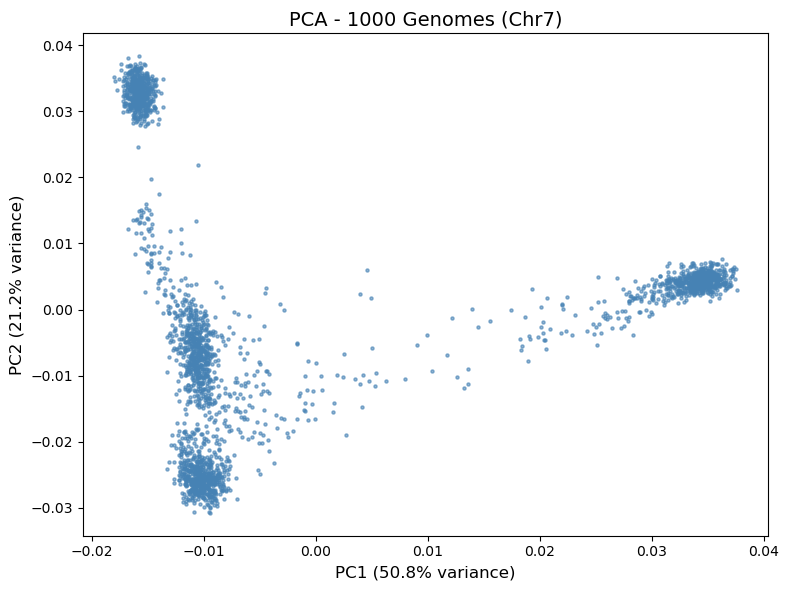

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load PCA ────────────────────────────────────────────────────────────
pca = pd.read_csv(
    "/Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_pca.eigenvec",
    delim_whitespace=True, header=None
)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, 21)]

# ── Load eigenvalues (for % variance explained) ──────────────────────────
eigenvalues = pd.read_csv(
    "/Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_pca.eigenval",
    header=None
)[0]
pct = eigenvalues / eigenvalues.sum() * 100

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(pca["PC1"], pca["PC2"], s=5, alpha=0.6, color="steelblue")

ax.set_xlabel(f"PC1 ({pct[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pct[1]:.1f}% variance)", fontsize=12)
ax.set_title("PCA - 1000 Genomes (Chr7)", fontsize=14)  # fixed: was labelled Chr1

plt.tight_layout()
plt.savefig("chr7_pca.png", dpi=150, bbox_inches="tight")
plt.show()

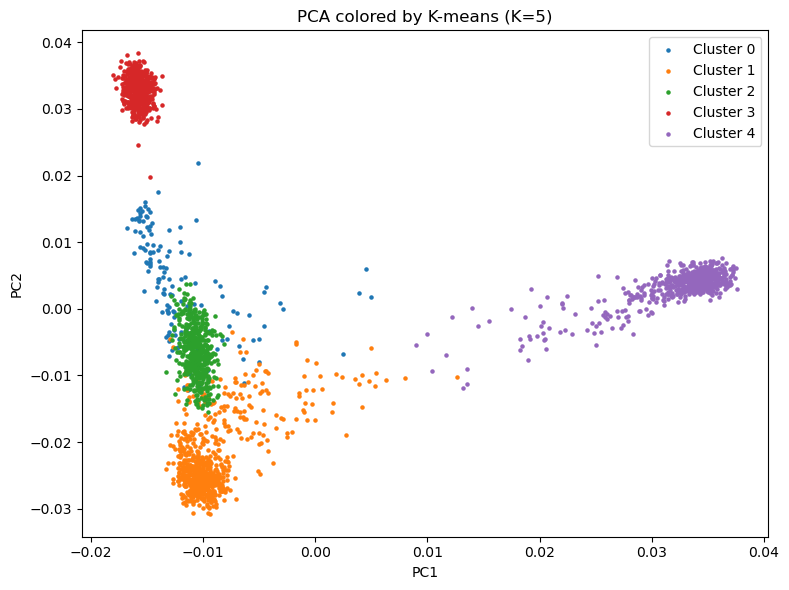

In [37]:
X = pca[[f"PC{i}" for i in range(1, 11)]].values  # use PC1–PC10

k = 5  # choose your K
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
pca["cluster"] = kmeans.fit_predict(X)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(pca["cluster"].unique()):
    df = pca[pca["cluster"] == c]
    ax.scatter(df["PC1"], df["PC2"], s=5, label=f"Cluster {c}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA colored by K-means (K={k})")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
%%bash
for K in 3 4 5 6 7; do
    /opt/anaconda3/envs/human_env/bin/admixture -j4 chr7_pruned_10k.bed $K
done

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 4 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x10000
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 1.759	Loglikelihood: -2.58358e+07	(delta): 1.52611e+07
2 (EM) 	Elapsed: 1.861	Loglikelihood: -

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

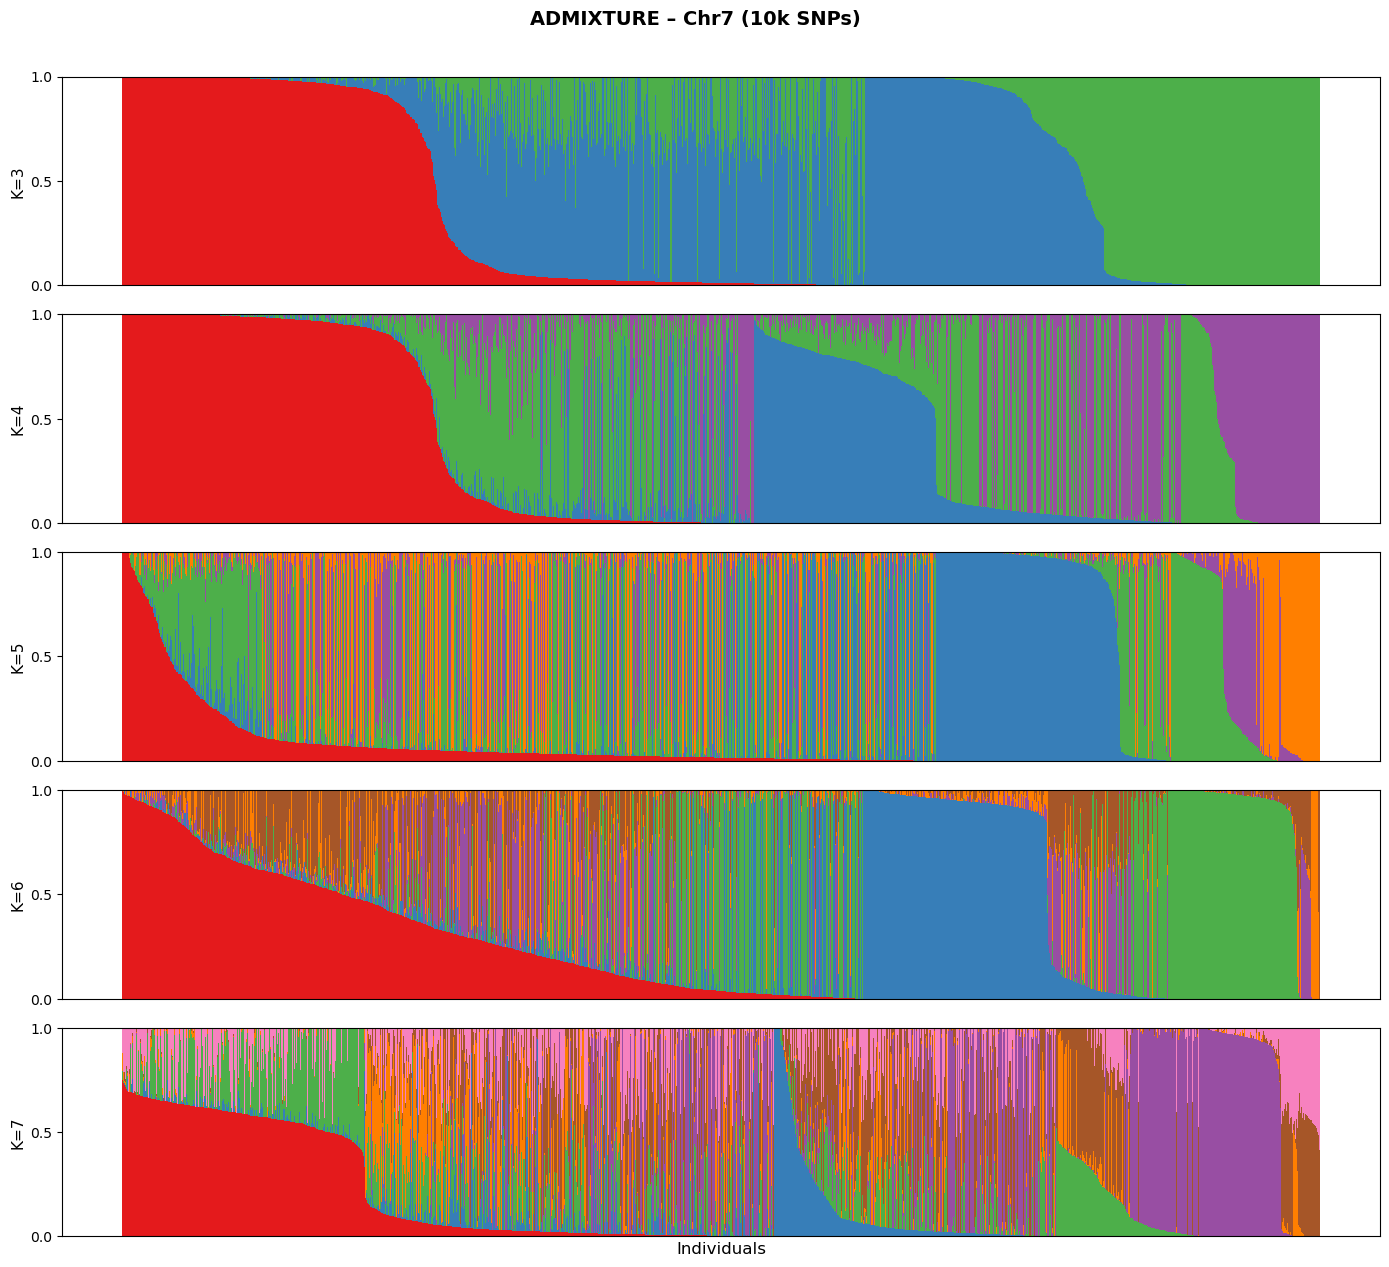

In [2]:
# ── Config ──────────────────────────────────────────────────────────────
prefix = "chr7_pruned_10k"
ks     = [3, 4, 5, 6, 7]

colors = [
    "#E41A1C", "#377EB8", "#4DAF4A",
    "#984EA3", "#FF7F00", "#A65628", "#F781BF"
]  # enough for K=7

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(ks), ncols=1,
    figsize=(14, 2.5 * len(ks)),
    sharex=True
)

for ax, k in zip(axes, ks):
    q = pd.read_table(f"{prefix}.{k}.Q", header=None, sep=r"\s+")
    q_sorted = q.sort_values(by=list(range(k)), ascending=False).reset_index(drop=True)

    bottom = [0] * len(q_sorted)
    for col in range(k):
        ax.bar(
            range(len(q_sorted)),
            q_sorted[col],
            bottom=bottom,
            color=colors[col],
            width=1.0,
            edgecolor="none"
        )
        bottom = [bottom[i] + q_sorted[col][i] for i in range(len(q_sorted))]

    ax.set_ylabel(f"K={k}", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(left=True, bottom=False, labelbottom=False)

axes[-1].set_xlabel("Individuals", fontsize=12)
fig.suptitle("ADMIXTURE – Chr7 (10k SNPs)", fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("admixture_barplots.png", dpi=150, bbox_inches="tight")
plt.show()